# Кредитный скоринг: предсказание дефолтов заёмщиков

Проект по бинарной классификации: по финансовым признакам клиента предсказываем вероятность серьёзной просрочки по кредиту в течение 2 лет.  
В работе сравниваются baseline (логистическая регрессия) и продвинутая модель (градиентный бустинг с балансировкой классов и подбором порога).

## Импорт библиотек

Подключаем библиотеки для работы с данными (`pandas`, `numpy`), визуализации (`matplotlib`, `seaborn`) и машинного обучения (`sklearn`).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

Exception ignored in PyObject_HasAttr(); consider using PyObject_HasAttrWithError(), PyObject_GetOptionalAttr() or PyObject_GetAttr():
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 491, in _call_with_frames_removed
AttributeError: partially initialized module 'pandas' from 'c:\Users\327\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\__init__.py' has no attribute '_pandas_parser_CAPI' (most likely due to a circular import)


KeyboardInterrupt: 

## Загрузка данных и переименование столбцов

Загружаем обучающую выборку из файла `train.csv`.  
Переименовываем англоязычные названия столбцов на русские для удобства анализа.

In [ ]:
df = pd.read_csv('train.csv')

rename_dict = {
    'Id': 'ID_клиента',
    'RevolvingUtilizationOfUnsecuredLines': 'Использование_кредитного_лимита',
    'age': 'Возраст',
    'NumberOfTime30-59DaysPastDueNotWorse': 'Просрочка_30_59_дней',
    'DebtRatio': 'Коэффициент_долга',
    'MonthlyIncome': 'Ежемесячный_доход',
    'NumberOfOpenCreditLinesAndLoans': 'Количество_открытых_кредитов',
    'NumberOfTimes90DaysLate': 'Просрочка_90_дней',
    'NumberRealEstateLoansOrLines': 'Кредиты_на_недвижимость',
    'NumberOfTime60-89DaysPastDueNotWorse': 'Просрочка_60_89_дней',
    'NumberOfDependents': 'Иждивенцы',
    'SeriousDlqin2yrs': 'Дефолт_за_2_года'
}

df.rename(columns=rename_dict, inplace=True)
df.head()


,ID_клиента,Дефолт_за_2_года,Использование_кредитного_лимита,Возраст,Просрочка_30_59_дней,Коэффициент_долга,Ежемесячный_доход,Количество_открытых_кредитов,Просрочка_90_дней,Кредиты_на_недвижимость,Просрочка_60_89_дней,Иждивенцы
0,1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
1,2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
2,3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
3,4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
4,5,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0


## Первичный осмотр данных

Проверяем размер таблицы, типы данных, наличие пропусков и основные статистики.  
Оцениваем баланс классов целевой переменной.

In [ ]:
df.shape

(104805, 12)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 104805 entries, 0 to 104804
Data columns (total 12 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   ID_клиента                       104805 non-null  int64  
 1   Дефолт_за_2_года                 104805 non-null  int64  
 2   Использование_кредитного_лимита  104805 non-null  float64
 3   Возраст                          104805 non-null  int64  
 4   Просрочка_30_59_дней             104805 non-null  int64  
 5   Коэффициент_долга                104805 non-null  float64
 6   Ежемесячный_доход                84024 non-null   float64
 7   Количество_открытых_кредитов     104805 non-null  int64  
 8   Просрочка_90_дней                104805 non-null  int64  
 9   Кредиты_на_недвижимость          104805 non-null  int64  
 10  Просрочка_60_89_дней             104805 non-null  int64  
 11  Иждивенцы                        102056 non-null  float64
dtypes: float64(4)

In [ ]:
df.isnull().sum()

ID_клиента                             0
Дефолт_за_2_года                       0
Использование_кредитного_лимита        0
Возраст                                0
Просрочка_30_59_дней                   0
Коэффициент_долга                      0
Ежемесячный_доход                  20781
Количество_открытых_кредитов           0
Просрочка_90_дней                      0
Кредиты_на_недвижимость                0
Просрочка_60_89_дней                   0
Иждивенцы                           2749
dtype: int64

In [ ]:
df.describe()

,ID_клиента,Дефолт_за_2_года,Использование_кредитного_лимита,Возраст,Просрочка_30_59_дней,Коэффициент_долга,Ежемесячный_доход,Количество_открытых_кредитов,Просрочка_90_дней,Кредиты_на_недвижимость,Просрочка_60_89_дней,Иждивенцы
count,104805.000000,104805.000000,104805.000000,104805.000000,104805.000000,104805.000000,8.402400e+04,104805.000000,104805.000000,104805.000000,104805.000000,102056.000000
mean,75013.710863,0.066314,5.602014,52.351128,0.416077,354.859470,6.684453e+03,8.454854,0.259988,1.019551,0.235571,0.756065
std,43324.043054,0.248831,217.389876,14.765944,4.139291,2169.182855,1.565313e+04,5.127986,4.115594,1.136847,4.101263,1.112162
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37508.000000,0.000000,0.029801,41.000000,0.000000,0.175026,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,74931.000000,0.000000,0.153984,52.000000,0.000000,0.366626,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112620.000000,0.000000,0.559168,63.000000,0.000000,0.867267,8.250000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,149999.000000,1.000000,29110.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,13.000000


In [ ]:
df['Дефолт_за_2_года'].value_counts(normalize=True)

Дефолт_за_2_года
0    0.933686
1    0.066314
Name: proportion, dtype: float64

## Визуальный анализ распределений

Строим гистограммы и ящики с усами, чтобы выявить выбросы, скошенность признаков и разреженность значений.

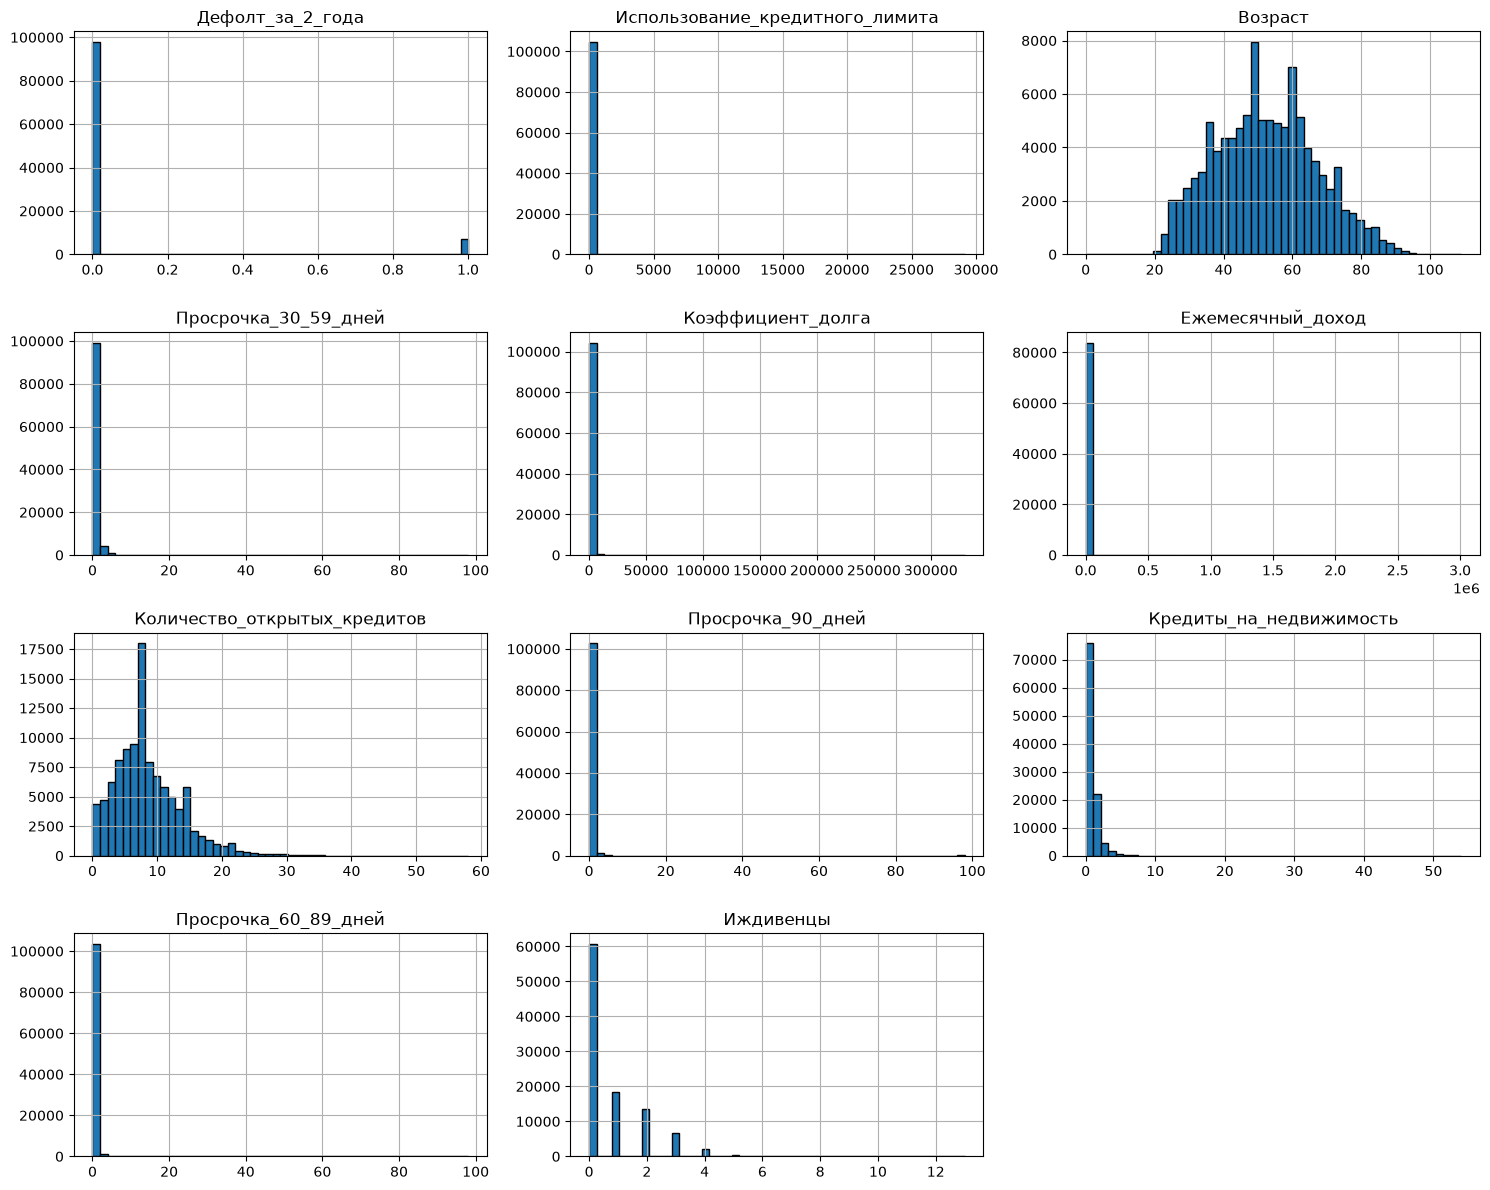

In [ ]:
cols_to_plot = df.drop(columns=['ID_клиента']).columns
df[cols_to_plot].hist(figsize=(15, 12), bins=50, edgecolor='black')
plt.tight_layout()
plt.show()

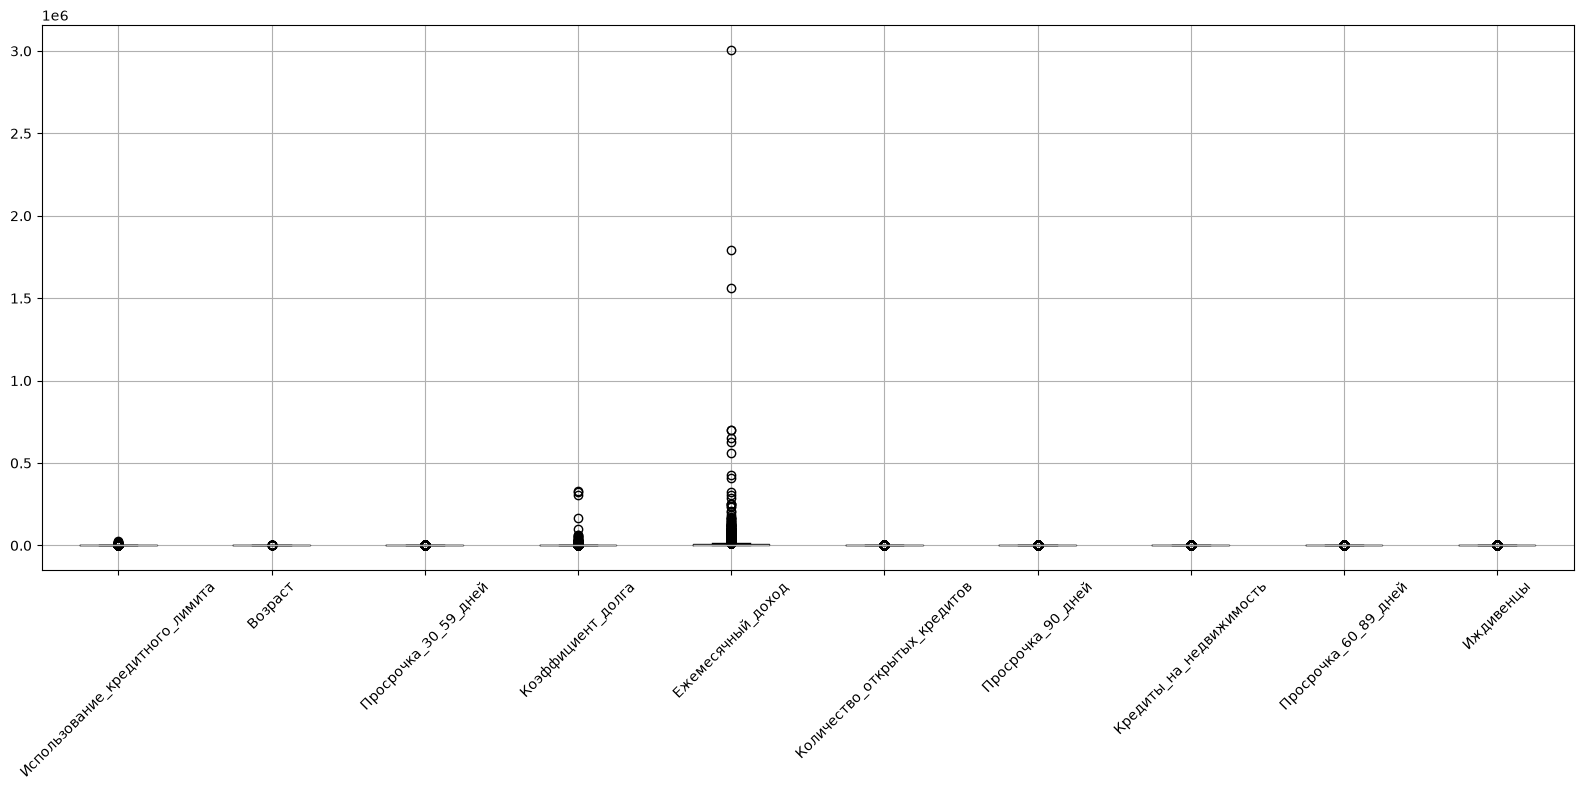

In [ ]:
cols_num = df.drop(columns=['ID_клиента', 'Дефолт_за_2_года']).columns
plt.figure(figsize=(16, 8))
df[cols_num].boxplot(rot=45)
plt.tight_layout()
plt.show()

In [ ]:
q1 = df[cols_num].quantile(0.25)
q3 = df[cols_num].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
downer = q1 - 1.5 * iqr
bounder = pd.DataFrame({"q1": q1, "q3": q3, "iqr": iqr, "downer bound": downer, "upper bound": upper})
print(bounder)

                                          q1           q3          iqr  \
Использование_кредитного_лимита     0.029801     0.559168     0.529367   
Возраст                            41.000000    63.000000    22.000000   
Просрочка_30_59_дней                0.000000     0.000000     0.000000   
Коэффициент_долга                   0.175026     0.867267     0.692241   
Ежемесячный_доход                3400.000000  8250.000000  4850.000000   
Количество_открытых_кредитов        5.000000    11.000000     6.000000   
Просрочка_90_дней                   0.000000     0.000000     0.000000   
Кредиты_на_недвижимость             0.000000     2.000000     2.000000   
Просрочка_60_89_дней                0.000000     0.000000     0.000000   
Иждивенцы                           0.000000     1.000000     1.000000   

                                 downer bound   upper bound  
Использование_кредитного_лимита     -0.764250      1.353219  
Возраст                              8.000000     96.000000  

## Обработка пропусков и выбросов

- Пропуски в `Ежемесячный_доход` и `Иждивенцы` заполняем медианой.  
- Выбросы ограничиваем 1-м и 99-м процентилями (винзоризация), чтобы уменьшить влияние экстремальных значений.

In [ ]:
med_income = df['Ежемесячный_доход'].median()
df['Ежемесячный_доход'] = df['Ежемесячный_доход'].fillna(med_income)

med_dep = df['Иждивенцы'].median()
df['Иждивенцы'] = df['Иждивенцы'].fillna(med_dep)

print(df[['Ежемесячный_доход', 'Иждивенцы']].isnull().sum())

Ежемесячный_доход    0
Иждивенцы            0
dtype: int64


In [ ]:
cols_to_process = df.drop(columns=['ID_клиента', 'Дефолт_за_2_года']).columns
for col in cols_to_process:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

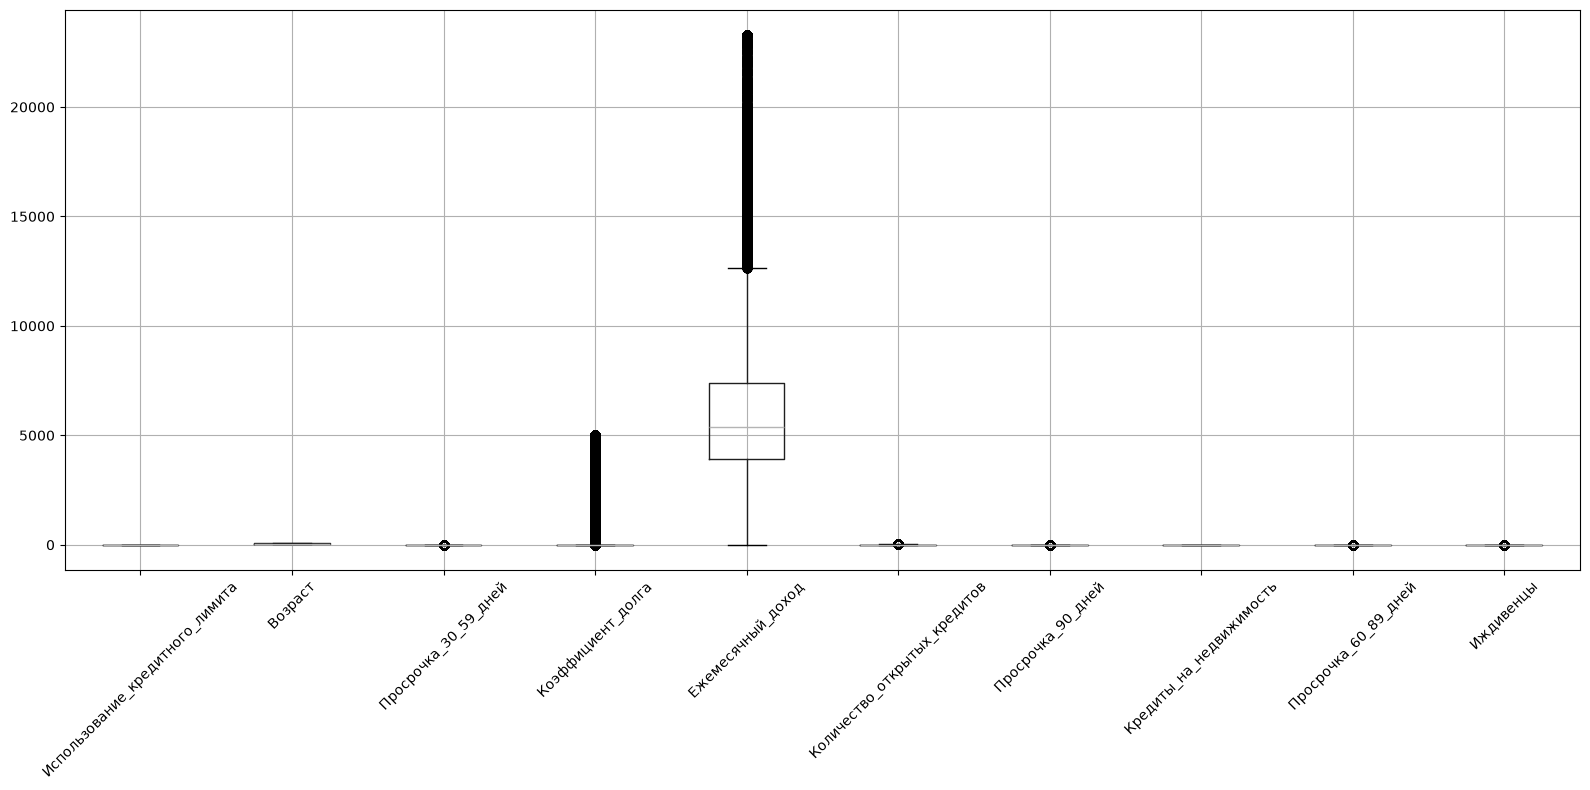

In [ ]:
plt.figure(figsize=(16, 8))
df[cols_to_process].boxplot(rot=45)
plt.tight_layout()
plt.show()

In [ ]:
test = pd.read_csv('test.csv')
rename_dict = {
    'Id': 'ID_клиента',
    'RevolvingUtilizationOfUnsecuredLines': 'Использование_кредитного_лимита',
    'age': 'Возраст',
    'NumberOfTime30-59DaysPastDueNotWorse': 'Просрочка_30_59_дней',
    'DebtRatio': 'Коэффициент_долга',
    'MonthlyIncome': 'Ежемесячный_доход',
    'NumberOfOpenCreditLinesAndLoans': 'Количество_открытых_кредитов',
    'NumberOfTimes90DaysLate': 'Просрочка_90_дней',
    'NumberRealEstateLoansOrLines': 'Кредиты_на_недвижимость',
    'NumberOfTime60-89DaysPastDueNotWorse': 'Просрочка_60_89_дней',
    'NumberOfDependents': 'Иждивенцы'
}
test.rename(columns=rename_dict, inplace=True)
print(test.shape)
test.head()
test.isnull().sum()

(45195, 11)


ID_клиента                            0
Использование_кредитного_лимита       0
Возраст                               0
Просрочка_30_59_дней                  0
Коэффициент_долга                     0
Ежемесячный_доход                  8950
Количество_открытых_кредитов          0
Просрочка_90_дней                     0
Кредиты_на_недвижимость               0
Просрочка_60_89_дней                  0
Иждивенцы                          1175
dtype: int64

In [ ]:
low_dict={}
up_dict={}

for col in cols_to_process:
    low_dict[col]=df[col].quantile(0.01)
    up_dict[col]=df[col].quantile(0.99)


In [ ]:
test["Ежемесячный_доход"]=test["Ежемесячный_доход"].fillna(med_income)
test["Иждивенцы"]=test["Иждивенцы"].fillna(med_dep)

for col in cols_to_process:
    test[col]=test[col].clip(lower=low_dict[col], upper=up_dict[col])

test.isnull().sum()
test.describe()


,ID_клиента,Использование_кредитного_лимита,Возраст,Просрочка_30_59_дней,Коэффициент_долга,Ежемесячный_доход,Количество_открытых_кредитов,Просрочка_90_дней,Кредиты_на_недвижимость,Просрочка_60_89_дней,Иждивенцы
count,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000
mean,74966.545702,0.320870,52.147782,0.246753,315.464900,6141.131192,8.392875,0.090231,0.990707,0.064233,0.729638
std,43249.355523,0.352120,14.678287,0.668324,906.102606,3811.943525,4.962675,0.409161,0.984997,0.292648,1.071001
min,0.000000,0.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37484.500000,0.030044,41.000000,0.000000,0.175159,3944.000000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75168.000000,0.154598,52.000000,0.000000,0.366169,5400.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112194.500000,0.558734,62.000000,0.000000,0.869708,7400.000000,11.000000,0.000000,2.000000,0.000000,1.000000
max,149997.000000,1.089811,87.000000,4.000000,5009.000000,23266.216000,24.000000,3.000000,4.000000,2.000000,4.000000


<Axes: >

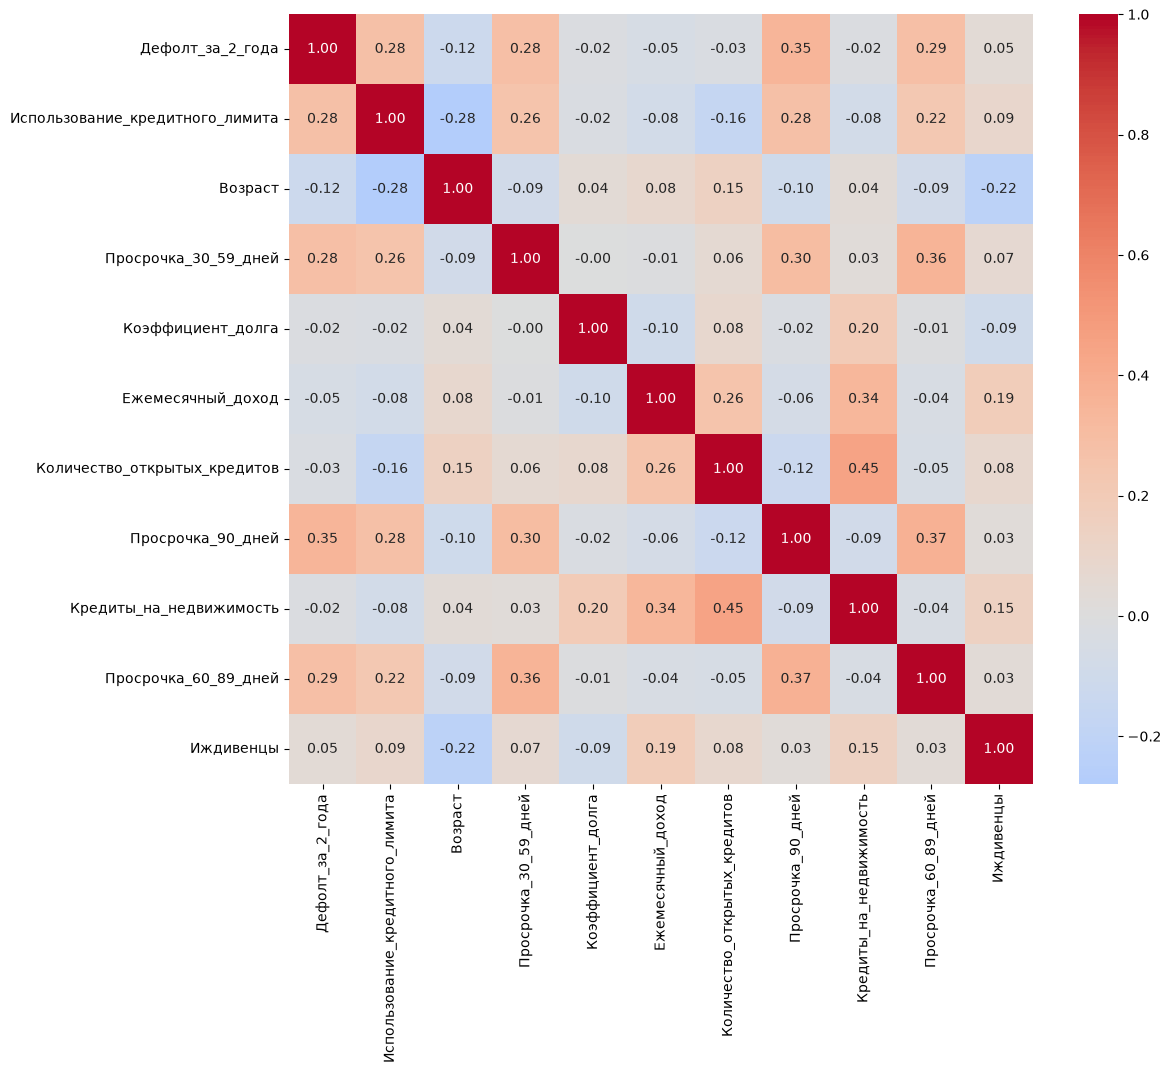

In [ ]:
corr_matrix = df.drop(columns='ID_клиента').corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')

## Разделение на обучающую и валидационную выборки

Делим данные на train (80%) и validation (20%) со стратификацией по целевой переменной, чтобы сохранить пропорцию классов.

In [ ]:
x = df.drop(columns=['ID_клиента', 'Дефолт_за_2_года'])
y=df['Дефолт_за_2_года']

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)
print(x_train.shape, x_val.shape)
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))


(83844, 10) (20961, 10)
Дефолт_за_2_года
0    0.933686
1    0.066314
Name: proportion, dtype: float64
Дефолт_за_2_года
0    0.933686
1    0.066314
Name: proportion, dtype: float64


## Baseline: логистическая регрессия

Масштабируем признаки с помощью RobustScaler (устойчив к выбросам) и обучаем логистическую регрессию.  
Оцениваем Accuracy на train и validation.

In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression

In [ ]:
scaler=RobustScaler() #  x_новое = x − медиана / IQR

scaler.fit(x_train)

x_train_scld=scaler.transform(x_train)
x_val_scld=scaler.transform(x_val)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(x_train_scld, y_train)

train_ac=model.score(x_train_scld, y_train)
print(train_ac)
val_ac=model.score(x_val_scld, y_val)
print(val_ac)

0.9379204236439102
0.9388865035065121


In [ ]:
y_pred=model.predict(x_val_scld)
y_proba=model.predict_proba(x_val_scld)[:, 1]

## Оценка Baseline

Рассчитываем основные метрики: Accuracy, Precision, Recall, F1, ROC-AUC, Gini, PR-AUC.  
Строим матрицу ошибок и ROC-кривую.

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay) 

acc=accuracy_score(y_val, y_pred)
prec=precision_score(y_val, y_pred)
rec=recall_score(y_val, y_pred)
f1=f1_score(y_val, y_pred)

print(f"accuracy : {acc:.4f} \nprecision: {prec:.4f} \nrecall: {rec:.4f} \nf1: {f1:.4f}")

accuracy : 0.9389 
precision: 0.6307 
recall: 0.1892 
f1: 0.2911


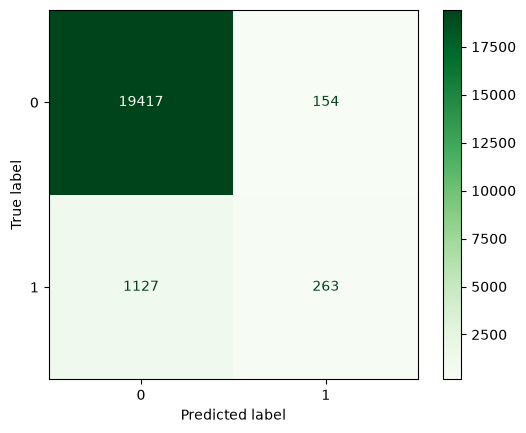

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Greens')


roc-auc:0.8559
gini: 0.7117


Text(0.5, 1.0, 'ROC-AUC, AUC=0.8559')

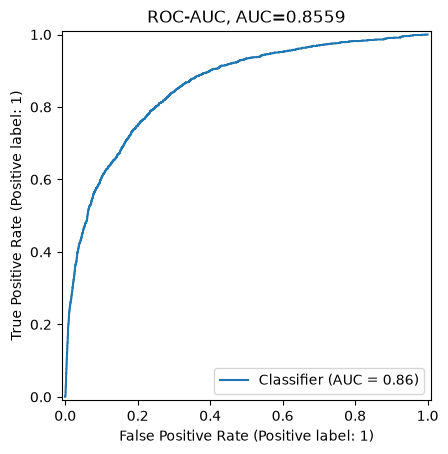

In [ ]:
from sklearn.metrics import (roc_auc_score, RocCurveDisplay)

roc_auc=roc_auc_score(y_val, y_proba)
gini=2*roc_auc-1
print(f"roc-auc:{roc_auc:.4f}\ngini: {gini:.4f}")
RocCurveDisplay.from_predictions(y_val, y_proba)
plt.title(f"ROC-AUC, AUC={roc_auc:.4F}")

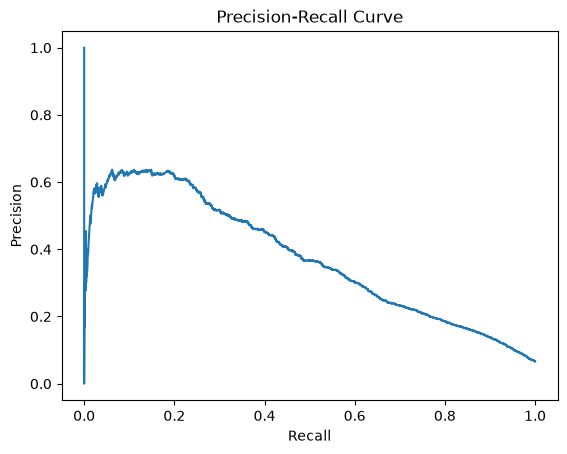

PR-AUC: 0.3738


In [ ]:
from sklearn.metrics import (average_precision_score, precision_recall_curve)

average_precision=average_precision_score(y_val, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_proba)

plt.figure()
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve")
plt.show()
print(f"PR-AUC: {average_precision:.4f}")

In [ ]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Gini', 'PR-AUC']
metrics_df=pd.DataFrame({
     'Метрика': metric_names,
    'Baseline': [acc, prec, rec, f1, roc_auc, gini, average_precision]
})
metrics_df.head(7)

,Метрика,Baseline
0,Accuracy,0.938887
1,Precision,0.630695
2,Recall,0.189209
3,F1-Score,0.291090
4,ROC-AUC,0.855857
5,Gini,0.711713
6,PR-AUC,0.373805


## Feature Engineering

Создаём новые признаки:  
- суммарное количество просрочек,  
- бинарный флаг использования лимита выше 50%,  
- логарифм дохода.

In [ ]:
def add_features(dataframe):
    df=dataframe.copy()
    df['Сумма_просрочек']=df['Просрочка_30_59_дней']+df['Просрочка_60_89_дней']+df['Просрочка_90_дней']
    df['Лимит_выше_50']=(df['Использование_кредитного_лимита']>0.5).astype(int)
    df['log_доход']=np.log1p(df['Ежемесячный_доход'])

    return df


In [ ]:
x_train_features=add_features(x_train)
x_val_features=add_features(x_val)

print(x_train_features.shape, x_val_features.shape)

(83844, 13) (20961, 13)


## Продвинутые модели

Сравниваем Random Forest и градиентный бустинг (HistGradientBoosting).  
Оцениваем их метрики на валидационной выборке.

In [ ]:
from sklearn.ensemble import RandomForestClassifier


In [ ]:
model_rf=RandomForestClassifier(n_estimators=200, random_state=42)

model_rf.fit(x_train_features, y_train)

y_pred_rf=model_rf.predict(x_val_features)
y_proba_rf=model_rf.predict_proba(x_val_features)[:, 1]

,Метрика,Baseline,RandomForest
0,Accuracy,0.938887,0.933591
1,Precision,0.630695,0.497854
2,Recall,0.189209,0.166906
3,F1-Score,0.291090,0.250000
4,ROC-AUC,0.855857,0.841411
5,Gini,0.711713,0.682823
6,PR-AUC,0.373805,0.339479


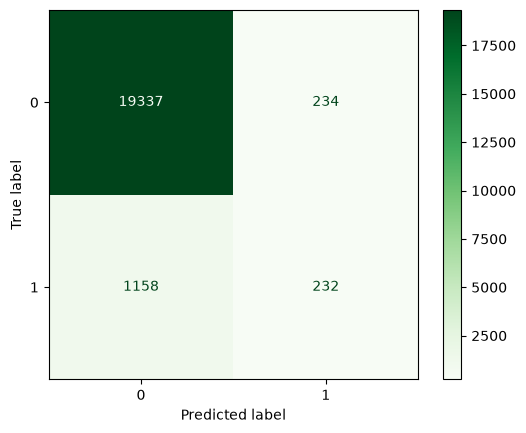

In [ ]:

ac_rf=accuracy_score(y_val, y_pred_rf)
prec_rf=precision_score(y_val, y_pred_rf)
rec_rf=recall_score(y_val, y_pred_rf)
f1_rf=f1_score(y_val, y_pred_rf)

roc_auc_rf=roc_auc_score(y_val, y_proba_rf)
gini_rf=2*roc_auc_rf - 1
average_precision_rf=average_precision_score(y_val, y_proba_rf)

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_rf, cmap='Greens')

metrics_rf_df=pd.DataFrame({
    'Метрика' : metric_names, 
    'RandomForest' : [ac_rf, prec_rf, rec_rf, f1_rf, roc_auc_rf, gini_rf, average_precision_rf]
})

metrics_df=metrics_df.merge(metrics_rf_df, on='Метрика')

metrics_df.head(7)


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

model_gb=HistGradientBoostingClassifier(random_state=42)
model_gb.fit(x_train_features, y_train)
y_pred_gb=model_gb.predict(x_val_features)
y_proba_gb=model_gb.predict_proba(x_val_features)[:,1]

ac_gb=accuracy_score(y_val, y_pred_gb)
prec_gb=precision_score(y_val, y_pred_gb)
rec_gb=recall_score(y_val, y_pred_gb)
f1_gb=f1_score(y_val, y_pred_gb)
roc_auc_gb=roc_auc_score(y_val, y_proba_gb)
gini_gb=2*roc_auc_gb -1
average_precision_gb=average_precision_score(y_val, y_proba_gb)

metrics_gb_df=pd.DataFrame({
    'Метрика' : metric_names,
    'Boosting' : [ac_gb, prec_gb, rec_gb, f1_gb, roc_auc_gb, gini_gb, average_precision_gb]
})

metrics_df = metrics_df.merge(metrics_gb_df, on='Метрика')



In [ ]:
df_baseline = pd.DataFrame({
    'Метрика': metric_names,
    'Baseline': [acc, prec, rec, f1, roc_auc, gini, average_precision]
})

df_rf = pd.DataFrame({
    'Метрика': metric_names,
    'RandomForest': [ac_rf, prec_rf, rec_rf, f1_rf, roc_auc_rf, gini_rf, average_precision_rf]
})

df_boosting = pd.DataFrame({
    'Метрика': metric_names,
    'Boosting': [ac_gb, prec_gb, rec_gb, f1_gb, roc_auc_gb, gini_gb, average_precision_gb]
})

metrics_df = df_baseline.merge(df_rf, on='Метрика')
metrics_df = metrics_df.merge(df_boosting, on='Метрика')

metrics_df.head(7)

,Метрика,Baseline,RandomForest,Boosting
0,Accuracy,0.938887,0.933591,0.937455
1,Precision,0.630695,0.497854,0.587196
2,Recall,0.189209,0.166906,0.191367
3,F1-Score,0.291090,0.250000,0.288660
4,ROC-AUC,0.855857,0.841411,0.863669
5,Gini,0.711713,0.682823,0.727338
6,PR-AUC,0.373805,0.339479,0.398622


## Балансировка классов и подбор порога

Обучаем бустинг с `class_weight='balanced'`, чтобы модель больше внимания уделяла редкому классу.  
Затем подбираем порог вероятности, максимизирующий F1-score.

In [ ]:
model_gb_new=HistGradientBoostingClassifier(random_state=42, class_weight='balanced')
model_gb_new.fit(x_train_features, y_train)
y_pred_gb_new=model_gb_new.predict(x_val_features)
y_proba_gb_new=model_gb_new.predict_proba(x_val_features)[:,1]
ac_gb_new=accuracy_score(y_val, y_pred_gb_new)
prec_gb_new=precision_score(y_val, y_pred_gb_new)
rec_gb_new=recall_score(y_val, y_pred_gb_new)
f1_gb_new=f1_score(y_val, y_pred_gb_new)
roc_auc_new=roc_auc_score(y_val, y_proba_gb_new)
gini=2*roc_auc_new - 1
average_precision_gb_new=average_precision_score(y_val, y_proba_gb_new)

boosting_new_df=pd.DataFrame({
    'Метрика' : metric_names,
    'Сбалансированный бустинг' : [ac_gb_new, prec_gb_new, rec_gb_new, f1_gb_new, roc_auc_new, gini, average_precision_gb_new]
})

metrics_df=metrics_df.merge(boosting_new_df, on='Метрика')

metrics_df.head(7)


,Метрика,Baseline,RandomForest,Boosting,Сбалансированный бустинг
0,Accuracy,0.938887,0.933591,0.937455,0.803635
1,Precision,0.630695,0.497854,0.587196,0.219432
2,Recall,0.189209,0.166906,0.191367,0.766906
3,F1-Score,0.291090,0.250000,0.288660,0.341229
4,ROC-AUC,0.855857,0.841411,0.863669,0.864207
5,Gini,0.711713,0.682823,0.727338,0.728415
6,PR-AUC,0.373805,0.339479,0.398622,0.387456


In [ ]:
from sklearn.model_selection import GridSearchCV
model_gridsearch=HistGradientBoostingClassifier(random_state=42)

param_grid={
    'learning_rate' : [0.05, 0.1],
    'max_depth' : [3, 5, None], 
    'min_samples_leaf' : [20, 50],
    'l2_regularization' : [0, 0.1, 1.0]
}

gsc=GridSearchCV(estimator=model_gridsearch, param_grid=param_grid, scoring='roc_auc', cv=3, n_jobs=-1, verbose=1)

gsc.fit(x_train_features, y_train)

best_model=gsc.best_estimator_
y_gs_pred=best_model.predict(x_val_features)
y_gs_proba=best_model.predict_proba(x_val_features)[:,1]

ac_gs=accuracy_score(y_val, y_gs_pred)
prec_gs=precision_score(y_val, y_gs_pred)
rec_gs=recall_score(y_val, y_gs_pred)
f1_gs=f1_score(y_val, y_gs_pred)
roc_auc_gs=roc_auc_score(y_val, y_gs_proba)
gini=2*roc_auc_gs - 1
average_precision_gs=average_precision_score(y_val, y_gs_proba)

gridsearch_df=pd.DataFrame({
    'Метрика' : metric_names,
    'GridSearchCV' : [ac_gs, prec_gs, rec_gs, f1_gs, roc_auc_gs, gini, average_precision_gs]
})  

metrics_df=metrics_df.merge(gridsearch_df, on='Метрика')
metrics_df.head(7)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


,Метрика,Baseline,RandomForest,Boosting,Сбалансированный бустинг,GridSearchCV_x,GridSearchCV_y
0,Accuracy,0.938887,0.933591,0.937455,0.803635,0.938314,0.938314
1,Precision,0.630695,0.497854,0.587196,0.219432,0.614118,0.614118
2,Recall,0.189209,0.166906,0.191367,0.766906,0.187770,0.187770
3,F1-Score,0.291090,0.250000,0.288660,0.341229,0.287603,0.287603
4,ROC-AUC,0.855857,0.841411,0.863669,0.864207,0.865598,0.865598
5,Gini,0.711713,0.682823,0.727338,0.728415,0.731197,0.731197
6,PR-AUC,0.373805,0.339479,0.398622,0.387456,0.399440,0.399440


In [ ]:
prec_vals, recall_vals, threshold = precision_recall_curve(y_val, y_proba_gb_new)
f1_scores = [ 2* (prec_vals[i]*recall_vals[i]) /(prec_vals[i]+recall_vals[i]) for i in range(len(threshold))]

best_idx=f1_scores.index(max(f1_scores))
best_threshold=threshold[best_idx]
best_f1=max(f1_scores)

y_pred_tuned=(y_proba_gb_new >= best_threshold).astype(int)

ac_tun=accuracy_score(y_val, y_pred_tuned)
prec_tun=precision_score(y_val, y_pred_tuned)
rec_tun=recall_score(y_val, y_pred_tuned)
f1_tun=f1_score(y_val, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_val, y_proba_gb_new)
gini_tuned = 2 * roc_auc_tuned - 1
average_precision_tuned = average_precision_score(y_val, y_proba_gb_new)

gridsearch_df_tuned=pd.DataFrame({
    'Метрика' : metric_names,
    'GridSearchCV_tuned' : [ac_tun, prec_tun, rec_tun, f1_tun, roc_auc_tuned, gini_tuned, average_precision_tuned]
})  

df_baseline = pd.DataFrame({
    'Метрика': metric_names,
    'Baseline': [acc, prec, rec, f1, roc_auc, gini, average_precision]
})

df_rf = pd.DataFrame({
    'Метрика': metric_names,
    'RandomForest': [ac_rf, prec_rf, rec_rf, f1_rf, roc_auc_rf, gini_rf, average_precision_rf]
})

df_boost = pd.DataFrame({
    'Метрика': metric_names,
    'Boosting': [ac_gb, prec_gb, rec_gb, f1_gb, roc_auc_gb, gini_gb, average_precision_gb]
})

df_boost_bal = pd.DataFrame({
    'Метрика': metric_names,
    'BalancedBoosting': [ac_gb_new, prec_gb_new, rec_gb_new, f1_gb_new, roc_auc_new, gini_gb, average_precision_gb_new]
})

df_boost_tuned = pd.DataFrame({
    'Метрика': metric_names,
    'Tuned': [ac_tun, prec_tun, rec_tun, f1_tun, roc_auc_tuned, gini_tuned, average_precision_tuned]
})

metrics_df = df_baseline
for df in [df_rf, df_boost, df_boost_bal, df_boost_tuned]:
    metrics_df = metrics_df.merge(df, on='Метрика')

metrics_df.head(7)

,Метрика,Baseline,RandomForest,Boosting,BalancedBoosting,Tuned
0,Accuracy,0.938887,0.933591,0.937455,0.803635,0.915176
1,Precision,0.630695,0.497854,0.587196,0.219432,0.392222
2,Recall,0.189209,0.166906,0.191367,0.766906,0.507914
3,F1-Score,0.291090,0.250000,0.288660,0.341229,0.442633
4,ROC-AUC,0.855857,0.841411,0.863669,0.864207,0.864207
5,Gini,0.731197,0.682823,0.727338,0.727338,0.728415
6,PR-AUC,0.373805,0.339479,0.398622,0.387456,0.387456


## Сравнение моделей и важность признаков

Строим ROC-кривые Baseline и продвинутой модели на одном графике.  
Сравниваем матрицы ошибок.  
Оцениваем важность признаков с помощью permutation importance.

Text(0, 0.5, 'True Positive Rate')

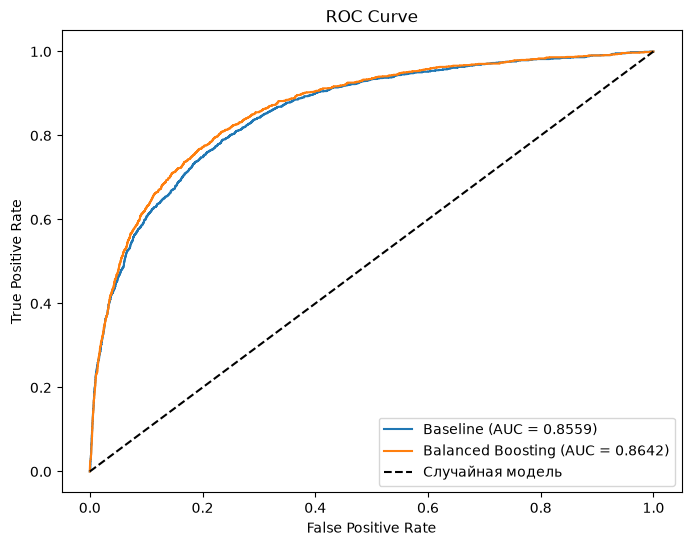

In [ ]:
from sklearn.metrics import roc_curve
fpr1, tpr1, thresholds1 = roc_curve(y_val, y_proba)
fpr2, tpr2, thresholds2 = roc_curve(y_val, y_proba_gb_new)
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f'Baseline (AUC = {roc_auc_score(y_val, y_proba):.4f})')
plt.plot(fpr2, tpr2, label=f'Balanced Boosting (AUC = {roc_auc_score(y_val, y_proba_gb_new):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

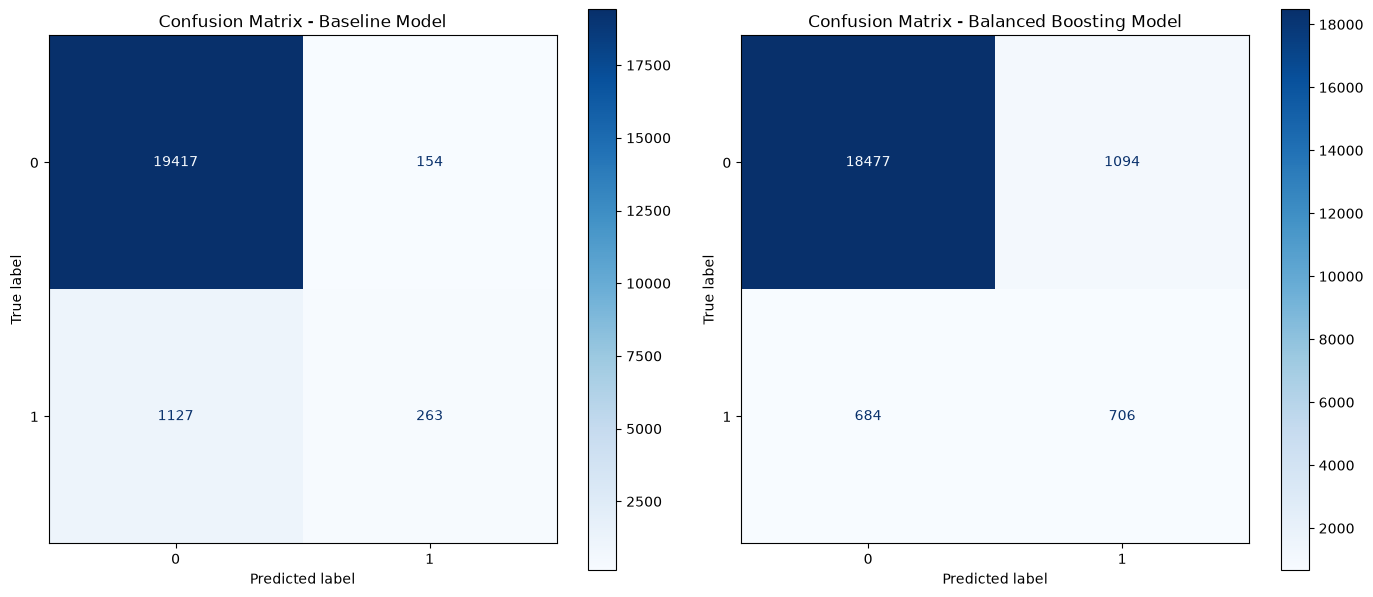

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay.from_predictions(y_val, y_pred, ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix - Baseline Model')
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_tuned, ax=axes[1], cmap='Blues')
axes[1].set_title('Confusion Matrix - Balanced Boosting Model')
plt.tight_layout()


Text(0.5, 1.0, 'Feature Importances - Balanced Boosting Model')

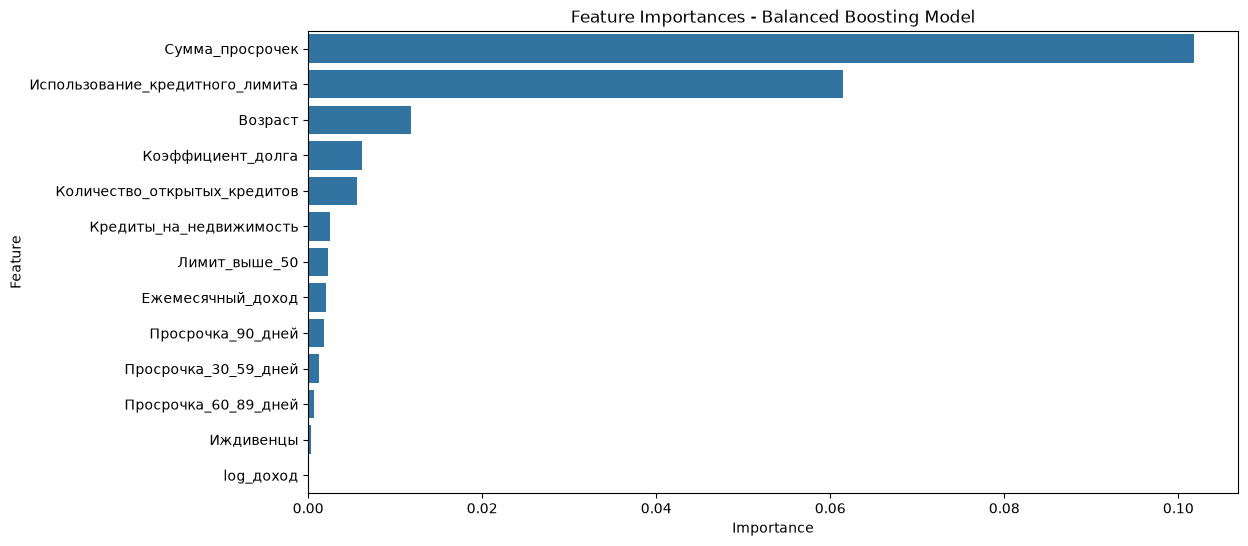

In [ ]:
from sklearn.inspection import permutation_importance

importances = permutation_importance(model_gb_new, x_val_features, y_val,scoring='roc_auc', n_repeats=10, random_state=42).importances_mean
feature_names = x_train_features.columns
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importances - Balanced Boosting Model')

## Итоги

Лучшая модель — сбалансированный градиентный бустинг с подобранным порогом.  
Она даёт ROC-AUC ≈ 0.864 и F1 ≈ 0.443 (против 0.856 и 0.291 у Baseline).  
Основные факторы риска: просрочки и использование кредитного лимита.


In [ ]:
requirements = """pandas
numpy
matplotlib
seaborn
scikit-learn
"""
with open('requirements.txt', 'w') as f:
    f.write(requirements)